# FIB-4 vs LSM Fibrosis Definitions: Matched Mortality Comparison (2017–2018)

The 2017–2018 NHANES cycle is the only one with both FIB-4 (lab-derived) and
liver stiffness measurement (LSM, via transient elastography / FibroScan).
This notebook compares how the choice of fibrosis definition affects the
matched mortality association.

**Three fibrosis definitions:**

| Definition | Fibrosis+ | Fibrosis− | Source |
|---|---|---|---|
| FIB-4 | ≥2.67 | <1.30 | Age, AST, ALT, platelets |
| LSM Castera/EASL | ≥9.5 kPa (F3/F4) | <7.1 kPa (F0–F1) | Transient elastography |
| LSM Eddowes/NAFLD | ≥9.7 kPa (F3/F4) | <8.2 kPa (F0–F1) | Transient elastography |

**Matching strategy:** Progressive PS matching (Steps 0–4) on age, sex, BMI,
SBP, and smoking. Step 4 is the primary comparison.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_style('whitegrid')

## Configuration

In [2]:
DERIVED = os.path.join(os.path.abspath('.'), 'data', 'derived')

WINDOW = 24  # 2017-2018 has max ~37m FU, only ~48% reach 24m

FIB4_HIGH = 2.67
FIB4_LOW  = 1.30

LSM_CUTPOINTS = {
    'Castera/EASL':   {'sig': 7.1, 'adv': 9.5, 'cir': 12.5},
    'Eddowes/NAFLD':  {'sig': 8.2, 'adv': 9.7, 'cir': 13.6},
}

UCOD_LABELS = {
    1: 'Heart disease', 2: 'Malignant neoplasms', 3: 'Chronic lower resp.',
    4: 'Accidents', 5: 'Cerebrovascular', 6: "Alzheimer's", 7: 'Diabetes',
    8: 'Influenza/pneumonia', 9: 'Nephritis', 10: 'All other causes',
}

MATCH_STEPS = [
    {'label': 'Step 1: Age, Sex',     'covariates': ['AGE', 'FEMALE']},
    {'label': 'Step 2: + BMI',        'covariates': ['AGE', 'FEMALE', 'BMXBMI']},
    {'label': 'Step 3: + SBP',        'covariates': ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN']},
    {'label': 'Step 4: + Smoking',    'covariates': ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER']},
]

## Load 2017–2018 data and define fibrosis

In [3]:
df = pd.read_parquet(os.path.join(DERIVED, '2017_2018.parquet'))
print(f'2017-2018: {len(df):,} adults')
print(f'LSM available: {df["LSM_KPA"].notna().sum():,}')
print(f'PERMTH_EXM range: {df["PERMTH_EXM"].min():.0f}\u2013{df["PERMTH_EXM"].max():.0f}')
print(f'% with \u226524m FU: {(df["PERMTH_EXM"]>=24).mean()*100:.0f}%')

2017-2018: 5,809 adults
LSM available: 5,091
PERMTH_EXM range: 0–37
% with ≥24m FU: 48%


In [4]:
# FIB-4
ok = (df['AST']>0) & (df['ALT']>0) & (df['PLATELETS']>0) & df['AGE'].notna()
df['FIB4'] = np.nan
df.loc[ok, 'FIB4'] = (df.loc[ok,'AGE'] * df.loc[ok,'AST']) / (
    df.loc[ok,'PLATELETS'] * np.sqrt(df.loc[ok,'ALT']))

df['FIBROSIS_FIB4'] = np.nan
df.loc[df['FIB4'] >= FIB4_HIGH, 'FIBROSIS_FIB4'] = 1
df.loc[df['FIB4'] < FIB4_LOW,   'FIBROSIS_FIB4'] = 0

# LSM definitions
for cp_name, cp in LSM_CUTPOINTS.items():
    col = f'FIBROSIS_LSM_{cp_name.replace("/","_")}'
    df[col] = np.nan
    ok_lsm = df['LSM_KPA'].notna()
    df.loc[ok_lsm & (df['LSM_KPA'] >= cp['adv']), col] = 1   # F3/F4
    df.loc[ok_lsm & (df['LSM_KPA'] < cp['sig']),  col] = 0   # F0-F1

# Summary
DEFINITIONS = [
    ('FIB-4 \u22652.67 vs <1.30', 'FIBROSIS_FIB4'),
    ('LSM Castera/EASL',       'FIBROSIS_LSM_Castera_EASL'),
    ('LSM Eddowes/NAFLD',      'FIBROSIS_LSM_Eddowes_NAFLD'),
]

for label, col in DEFINITIONS:
    n_plus = int((df[col]==1).sum())
    n_minus = int((df[col]==0).sum())
    print(f'{label}: Fib+={n_plus}, Fib\u2212={n_minus}')

FIB-4 ≥2.67 vs <1.30: Fib+=189, Fib−=3573
LSM Castera/EASL: Fib+=386, Fib−=4274
LSM Eddowes/NAFLD: Fib+=370, Fib−=4536


## Define outcomes

In [5]:
w = f'_{WINDOW}m'
df[f'FU{w}']    = df['PERMTH_EXM'].clip(upper=WINDOW)
df[f'PY{w}']    = df[f'FU{w}'] / 12.0
df[f'DEATH{w}'] = ((df['MORTSTAT']==1) & (df['PERMTH_EXM']<=WINDOW)).astype(int)
for code in UCOD_LABELS:
    df[f'D_UCOD{code}{w}'] = ((df[f'DEATH{w}']==1) & (df['UCOD_LEADING']==code)).astype(int)

print(f'{WINDOW}m window: {df[f"DEATH{w}"].sum()} deaths')

24m window: 113 deaths


## Core functions

In [6]:
def propensity_match(df, fib_col, covariates, caliper=0.2, random_state=42):
    sub = df.dropna(subset=[fib_col] + covariates).copy()
    treated = sub[sub[fib_col]==1]
    control = sub[sub[fib_col]==0]
    if len(treated) < 5 or len(control) < 5:
        return pd.DataFrame(), len(treated), len(control)
    X = sub[covariates].copy()
    for c in covariates:
        if sub[c].nunique() > 2:
            X[c] = (X[c] - X[c].mean()) / (X[c].std() + 1e-8)
    y = sub[fib_col].astype(int)
    try:
        model = sm.Logit(y, sm.add_constant(X)).fit(disp=0, maxiter=100)
        sub['ps'] = model.predict(sm.add_constant(X))
    except Exception as e:
        print(f'  PS model failed: {e}')
        return pd.DataFrame(), len(treated), len(control)
    cal = caliper * sub['ps'].std()
    treated_idx = sub[sub[fib_col]==1].index.tolist()
    control_idx = sub[sub[fib_col]==0].index.tolist()
    rng = np.random.default_rng(random_state)
    rng.shuffle(treated_idx)
    matched_t, matched_c = [], []
    used = set()
    ctrl_ps = sub.loc[control_idx, 'ps'].values
    ctrl_arr = np.array(control_idx)
    for t_i in treated_idx:
        dists = np.abs(ctrl_ps - sub.loc[t_i, 'ps'])
        mask = np.array([c not in used for c in ctrl_arr])
        dists[~mask] = np.inf
        best = np.argmin(dists)
        if dists[best] <= cal:
            matched_t.append(t_i)
            matched_c.append(ctrl_arr[best])
            used.add(ctrl_arr[best])
    if not matched_t:
        return pd.DataFrame(), len(treated), len(control)
    mt = sub.loc[matched_t].copy(); mt['MATCH_ID'] = range(len(matched_t))
    mc = sub.loc[matched_c].copy(); mc['MATCH_ID'] = range(len(matched_c))
    return pd.concat([mt, mc], ignore_index=True), len(treated), len(control)


def covariate_balance(df, fib_col, covariates):
    rows = []
    for c in covariates:
        t = df.loc[df[fib_col]==1, c].dropna()
        ctrl = df.loc[df[fib_col]==0, c].dropna()
        if len(t)==0 or len(ctrl)==0:
            rows.append({'Covariate': c, 'SMD': np.nan})
            continue
        pooled_std = np.sqrt((t.var() + ctrl.var()) / 2)
        smd = (t.mean() - ctrl.mean()) / pooled_std if pooled_std > 0 else 0
        rows.append({'Covariate': c, 'SMD': round(smd, 3)})
    return pd.DataFrame(rows)


def risk_ratio(df, fib_col, window):
    w = f'_{window}m'
    t = df[df[fib_col]==1]; c = df[df[fib_col]==0]
    n1, n0 = len(t), len(c)
    d1 = t[f'DEATH{w}'].sum(); d0 = c[f'DEATH{w}'].sum()
    if n1==0 or n0==0 or d0==0:
        return {'RR':np.nan,'lo':np.nan,'hi':np.nan,'d1':int(d1),'d0':int(d0),'n1':n1,'n0':n0}
    r1, r0 = d1/n1, d0/n0
    rr = r1/r0
    se = np.sqrt(1/d1 - 1/n1 + 1/d0 - 1/n0) if d1>0 else np.nan
    lo = np.exp(np.log(rr)-1.96*se) if np.isfinite(se) else np.nan
    hi = np.exp(np.log(rr)+1.96*se) if np.isfinite(se) else np.nan
    return {'RR':round(rr,2),'lo':round(lo,2),'hi':round(hi,2),
            'd1':int(d1),'d0':int(d0),'n1':n1,'n0':n0}


def plot_km(df, fib_col, window, title, labels=None):
    if labels is None:
        labels = {1: 'Fibrosis+', 0: 'Fibrosis\u2212'}
    w = f'_{window}m'
    sub = df[df[fib_col].notna()].copy()
    sub['T'] = sub[f'FU{w}']
    sub['E'] = sub[f'DEATH{w}']
    fig, ax = plt.subplots(figsize=(7, 5))
    kmf = KaplanMeierFitter()
    colors = {1: '#d62728', 0: '#2ca02c'}
    for val in [0, 1]:
        grp = sub[sub[fib_col] == val]
        if len(grp) == 0: continue
        kmf.fit(grp['T'], grp['E'],
                label=f"{labels[val]} (n={len(grp):,}, d={int(grp['E'].sum()):,})")
        kmf.plot_survival_function(ax=ax, color=colors[val], ci_show=True, ci_alpha=0.15)
    g1 = sub[sub[fib_col]==1]; g0 = sub[sub[fib_col]==0]
    if len(g1)>0 and len(g0)>0 and (g1['E'].sum()+g0['E'].sum())>0:
        lr = logrank_test(g1['T'], g0['T'], g1['E'], g0['E'])
        pstr = 'p < 0.001' if lr.p_value < 0.001 else f'p = {lr.p_value:.3f}'
        ax.text(0.98, 0.02, f'Log-rank {pstr}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Months from MEC exam')
    ax.set_ylabel('Survival probability')
    ax.set_title(title)
    ax.set_xlim(0, window)
    ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.02))
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout(); plt.show()

## Unmatched KM curves: all three definitions

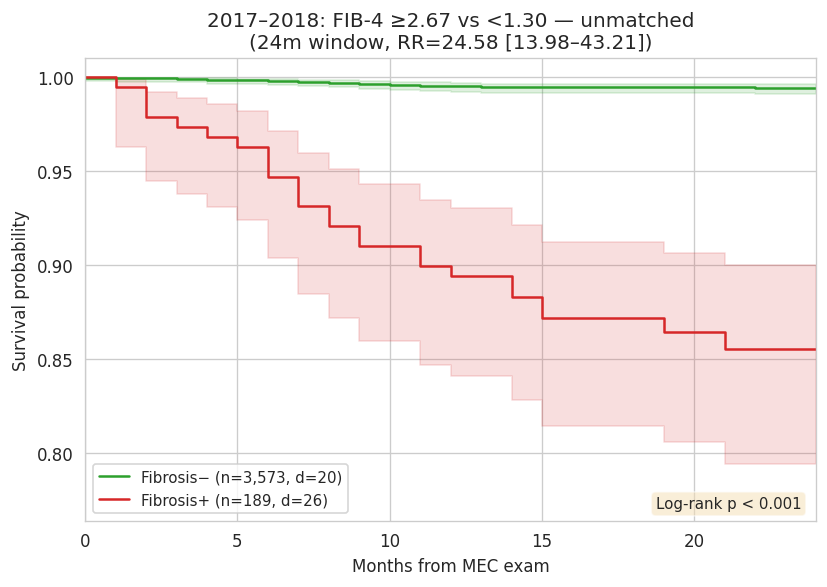

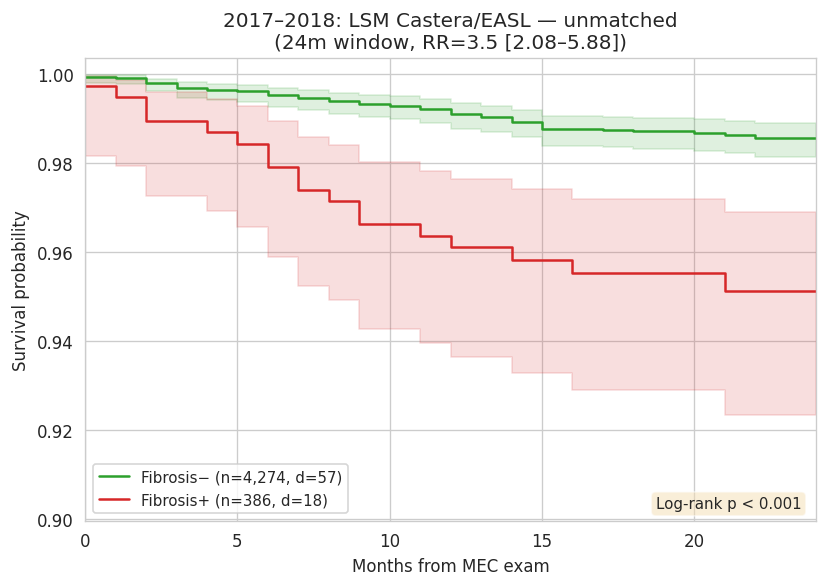

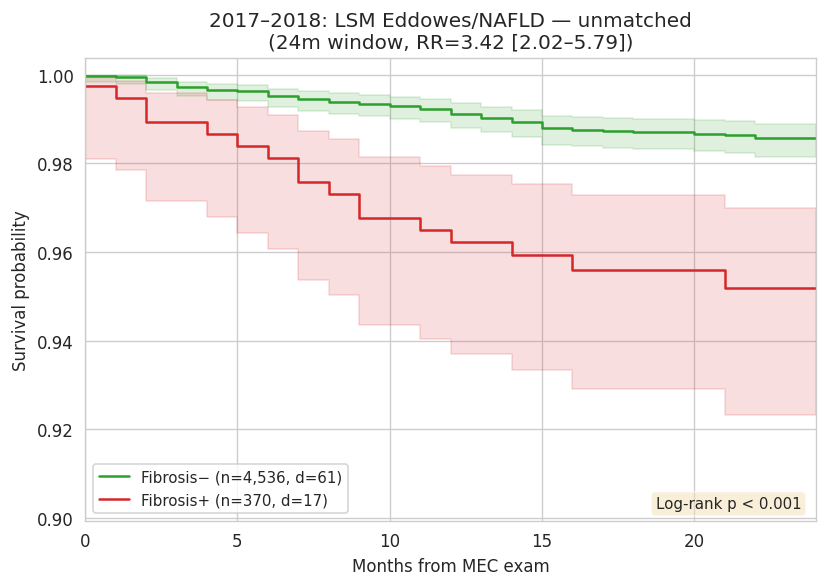

In [7]:
for label, col in DEFINITIONS:
    rr = risk_ratio(df, col, WINDOW)
    rr_str = f'RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]' if pd.notna(rr['RR']) else 'RR=n/a'
    plot_km(df, col, WINDOW,
            f'2017\u20132018: {label} \u2014 unmatched\n'
            f'({WINDOW}m window, {rr_str})')

## Cross-tabulation: FIB-4 vs LSM classification

How much do the three definitions agree on who is fibrosis+ vs fibrosis−?

In [8]:
# Cross-tab FIB-4 vs LSM Castera
for cp_name in LSM_CUTPOINTS:
    lsm_col = f'FIBROSIS_LSM_{cp_name.replace("/","_")}'
    sub = df.dropna(subset=['FIBROSIS_FIB4', lsm_col])
    ct = pd.crosstab(
        sub['FIBROSIS_FIB4'].map({1: 'FIB4+', 0: 'FIB4\u2212'}),
        sub[lsm_col].map({1: f'LSM+', 0: f'LSM\u2212'}),
        margins=True
    )
    print(f'\nFIB-4 vs LSM {cp_name} (n={len(sub):,}):')
    display(ct)
    
    # Agreement
    agree = ((sub['FIBROSIS_FIB4']==1) & (sub[lsm_col]==1)).sum() + \
            ((sub['FIBROSIS_FIB4']==0) & (sub[lsm_col]==0)).sum()
    pct = agree / len(sub) * 100
    print(f'  Agreement: {agree}/{len(sub)} ({pct:.1f}%)')
    
    # FIB4+ who are also LSM+
    fib4_plus = sub[sub['FIBROSIS_FIB4']==1]
    both = (fib4_plus[lsm_col]==1).sum()
    print(f'  FIB4+ also LSM+: {both}/{len(fib4_plus)} ({both/len(fib4_plus)*100:.0f}%)')
    
    lsm_plus = sub[sub[lsm_col]==1]
    both2 = (lsm_plus['FIBROSIS_FIB4']==1).sum()
    print(f'  LSM+ also FIB4+: {both2}/{len(lsm_plus)} ({both2/len(lsm_plus)*100:.0f}%)')


FIB-4 vs LSM Castera/EASL (n=3,266):


FIBROSIS_LSM_Castera_EASL,LSM+,LSM−,All
FIBROSIS_FIB4,,,
FIB4+,55,86,141
FIB4−,196,2929,3125
All,251,3015,3266


  Agreement: 2984/3266 (91.4%)
  FIB4+ also LSM+: 55/141 (39%)
  LSM+ also FIB4+: 55/251 (22%)

FIB-4 vs LSM Eddowes/NAFLD (n=3,429):


FIBROSIS_LSM_Eddowes_NAFLD,LSM+,LSM−,All
FIBROSIS_FIB4,,,
FIB4+,54,94,148
FIB4−,188,3093,3281
All,242,3187,3429


  Agreement: 3147/3429 (91.8%)
  FIB4+ also LSM+: 54/148 (36%)
  LSM+ also FIB4+: 54/242 (22%)


## Progressive matching: all three definitions

In [9]:
all_covs = ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'SMOKE_EVER']
step_order = ['Step 0: Crude'] + [s['label'] for s in MATCH_STEPS]

# Store results: results[def_label][step_label] = {matched, rr, n_pairs, ...}
results = {}

for def_label, fib_col in DEFINITIONS:
    results[def_label] = {}
    print(f'\n{"="*60}')
    print(f'{def_label}')
    print(f'{"="*60}')
    
    # Step 0: Crude
    sub0 = df[df[fib_col].notna()].copy()
    rr0 = risk_ratio(sub0, fib_col, WINDOW)
    results[def_label]['Step 0: Crude'] = {
        'matched': sub0, 'rr': rr0, 'n_pairs': None,
        'covariates': [], 'fib_col': fib_col,
        'n_t': int((sub0[fib_col]==1).sum()),
        'n_c': int((sub0[fib_col]==0).sum()),
    }
    rr_str = f'RR={rr0["RR"]} [{rr0["lo"]}\u2013{rr0["hi"]}]' if pd.notna(rr0['RR']) else 'n/a'
    print(f'  Crude: n+={rr0["n1"]}, n\u2212={rr0["n0"]}, d+={rr0["d1"]}, d\u2212={rr0["d0"]}, {rr_str}')
    
    for step in MATCH_STEPS:
        covs = step['covariates']
        label = step['label']
        mdf, n_t, n_c = propensity_match(df, fib_col, covs)
        if len(mdf) == 0:
            results[def_label][label] = {
                'matched': pd.DataFrame(), 'rr': None, 'n_pairs': 0,
                'covariates': covs, 'fib_col': fib_col, 'n_t': n_t, 'n_c': n_c,
            }
            print(f'  {label}: no matches')
            continue
        
        # Re-add outcomes to matched data
        ww = f'_{WINDOW}m'
        mdf[f'FU{ww}'] = mdf['PERMTH_EXM'].clip(upper=WINDOW)
        mdf[f'PY{ww}'] = mdf[f'FU{ww}'] / 12.0
        mdf[f'DEATH{ww}'] = ((mdf['MORTSTAT']==1) & (mdf['PERMTH_EXM']<=WINDOW)).astype(int)
        for code in UCOD_LABELS:
            mdf[f'D_UCOD{code}{ww}'] = ((mdf[f'DEATH{ww}']==1) & (mdf['UCOD_LEADING']==code)).astype(int)
        
        n_pairs = int((mdf[fib_col]==1).sum())
        rr = risk_ratio(mdf, fib_col, WINDOW)
        results[def_label][label] = {
            'matched': mdf, 'rr': rr, 'n_pairs': n_pairs,
            'covariates': covs, 'fib_col': fib_col, 'n_t': n_t, 'n_c': n_c,
        }
        
        rr_str = f'RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]' if pd.notna(rr['RR']) else 'n/a'
        bal = covariate_balance(mdf, fib_col, all_covs)
        bal_str = ', '.join(f'{r["Covariate"]}={abs(r["SMD"]):.2f}'
                           for _, r in bal.iterrows() if pd.notna(r['SMD']))
        print(f'  {label}: {n_pairs} pairs, d+={rr["d1"]}, d\u2212={rr["d0"]}, {rr_str}')
        print(f'    Balance: {bal_str}')


FIB-4 ≥2.67 vs <1.30
  Crude: n+=189, n−=3573, d+=26, d−=20, RR=24.58 [13.98–43.21]
  Step 1: Age, Sex: 152 pairs, d+=20, d−=4, RR=5.0 [1.75–14.28]
    Balance: AGE=0.01, FEMALE=0.08, BMXBMI=0.28, SBP_MEAN=0.05, SMOKE_EVER=0.03


  Step 2: + BMI: 141 pairs, d+=16, d−=3, RR=5.33 [1.59–17.9]
    Balance: AGE=0.01, FEMALE=0.04, BMXBMI=0.01, SBP_MEAN=0.23, SMOKE_EVER=0.01


  Step 3: + SBP: 133 pairs, d+=13, d−=2, RR=6.5 [1.5–28.25]
    Balance: AGE=0.04, FEMALE=0.08, BMXBMI=0.13, SBP_MEAN=0.02, SMOKE_EVER=0.01
  Step 4: + Smoking: 135 pairs, d+=13, d−=2, RR=6.5 [1.5–28.26]
    Balance: AGE=0.05, FEMALE=0.10, BMXBMI=0.14, SBP_MEAN=0.07, SMOKE_EVER=0.07

LSM Castera/EASL
  Crude: n+=386, n−=4274, d+=18, d−=57, RR=3.5 [2.08–5.88]


  Step 1: Age, Sex: 386 pairs, d+=18, d−=1, RR=18.0 [2.41–134.17]
    Balance: AGE=0.00, FEMALE=0.00, BMXBMI=1.08, SBP_MEAN=0.34, SMOKE_EVER=0.10
  Step 2: + BMI: 349 pairs, d+=14, d−=4, RR=3.5 [1.16–10.53]
    Balance: AGE=0.02, FEMALE=0.05, BMXBMI=0.03, SBP_MEAN=0.13, SMOKE_EVER=0.07


  Step 3: + SBP: 332 pairs, d+=15, d−=5, RR=3.0 [1.1–8.16]
    Balance: AGE=0.04, FEMALE=0.03, BMXBMI=0.03, SBP_MEAN=0.01, SMOKE_EVER=0.01
  Step 4: + Smoking: 333 pairs, d+=15, d−=5, RR=3.0 [1.1–8.16]
    Balance: AGE=0.08, FEMALE=0.03, BMXBMI=0.02, SBP_MEAN=0.00, SMOKE_EVER=0.11

LSM Eddowes/NAFLD
  Crude: n+=370, n−=4536, d+=17, d−=61, RR=3.42 [2.02–5.79]


  Step 1: Age, Sex: 370 pairs, d+=17, d−=1, RR=17.0 [2.27–127.09]
    Balance: AGE=0.00, FEMALE=0.00, BMXBMI=1.09, SBP_MEAN=0.35, SMOKE_EVER=0.12
  Step 2: + BMI: 342 pairs, d+=13, d−=7, RR=1.86 [0.75–4.6]
    Balance: AGE=0.07, FEMALE=0.01, BMXBMI=0.02, SBP_MEAN=0.03, SMOKE_EVER=0.00


  Step 3: + SBP: 327 pairs, d+=14, d−=4, RR=3.5 [1.16–10.52]
    Balance: AGE=0.04, FEMALE=0.03, BMXBMI=0.03, SBP_MEAN=0.02, SMOKE_EVER=0.09
  Step 4: + Smoking: 329 pairs, d+=14, d−=5, RR=2.8 [1.02–7.68]
    Balance: AGE=0.02, FEMALE=0.01, BMXBMI=0.02, SBP_MEAN=0.08, SMOKE_EVER=0.02


### Summary table

In [10]:
summary_rows = []
for def_label, fib_col in DEFINITIONS:
    for step_label in step_order:
        res = results[def_label].get(step_label)
        if res is None:
            continue
        rr = res['rr']
        row = {
            'Definition': def_label,
            'Step': step_label,
            'N+ avail': res['n_t'],
            'N\u2212 avail': res['n_c'],
            'Pairs': res['n_pairs'] if res['n_pairs'] is not None else f"{res['n_t']}v{res['n_c']}",
        }
        if rr and pd.notna(rr['RR']):
            row.update({'d+': rr['d1'], 'd\u2212': rr['d0'],
                        'RR': rr['RR'], '95% CI': f"{rr['lo']}\u2013{rr['hi']}"})
        else:
            row.update({'d+': rr['d1'] if rr else '\u2014', 'd\u2212': rr['d0'] if rr else '\u2014',
                        'RR': '\u2014', '95% CI': '\u2014'})
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

,Definition,Step,N+ avail,N− avail,Pairs,d+,d−,RR,95% CI
0,FIB-4 ≥2.67 vs <1.30,Step 0: Crude,189,3573,189v3573,26,20,24.58,13.98–43.21
1,FIB-4 ≥2.67 vs <1.30,"Step 1: Age, Sex",189,3573,152,20,4,5.00,1.75–14.28
2,FIB-4 ≥2.67 vs <1.30,Step 2: + BMI,181,3534,141,16,3,5.33,1.59–17.9
3,FIB-4 ≥2.67 vs <1.30,Step 3: + SBP,174,3390,133,13,2,6.50,1.5–28.25
4,FIB-4 ≥2.67 vs <1.30,Step 4: + Smoking,174,3390,135,13,2,6.50,1.5–28.26
5,LSM Castera/EASL,Step 0: Crude,386,4274,386v4274,18,57,3.50,2.08–5.88
6,LSM Castera/EASL,"Step 1: Age, Sex",386,4274,386,18,1,18.00,2.41–134.17
7,LSM Castera/EASL,Step 2: + BMI,379,4240,349,14,4,3.50,1.16–10.53
8,LSM Castera/EASL,Step 3: + SBP,362,4071,332,15,5,3.00,1.1–8.16
9,LSM Castera/EASL,Step 4: + Smoking,362,4071,333,15,5,3.00,1.1–8.16


## Matched KM curves: Step 4 comparison across definitions

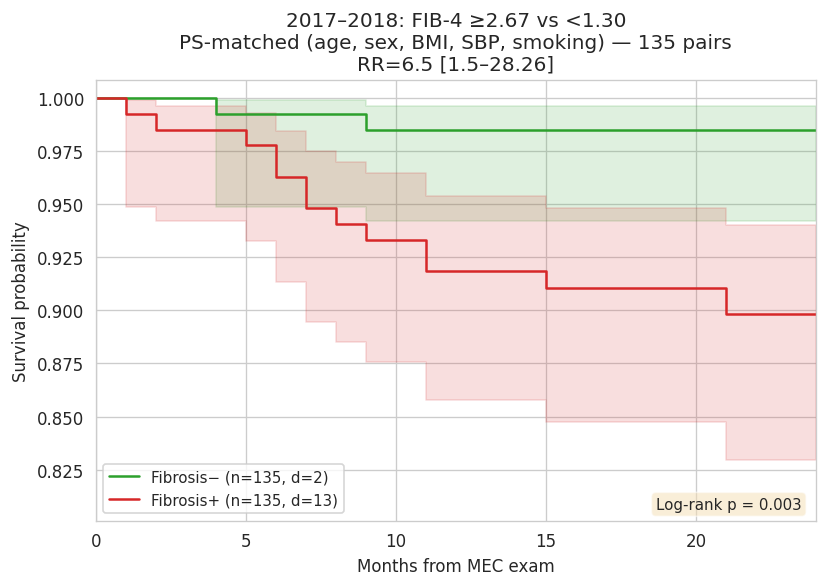

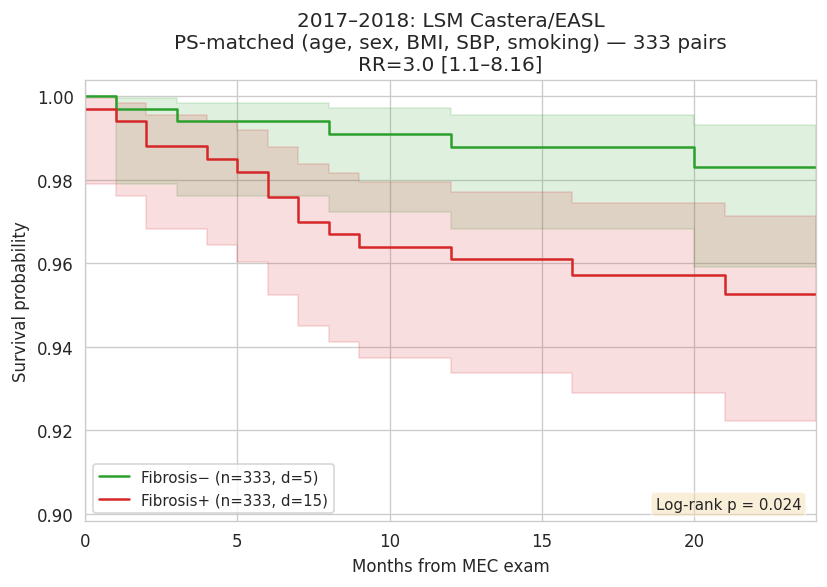

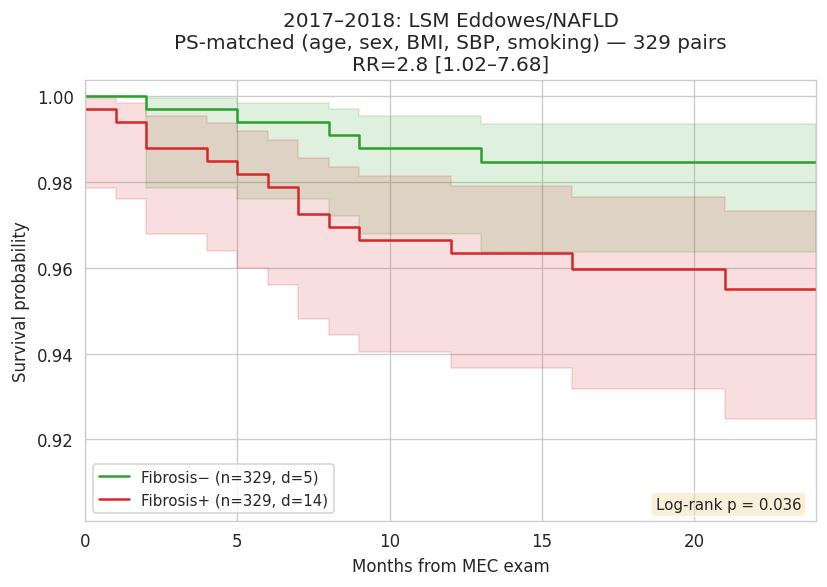

In [11]:
step4_label = 'Step 4: + Smoking'

for def_label, fib_col in DEFINITIONS:
    res = results[def_label].get(step4_label)
    if res is None or len(res['matched']) == 0:
        print(f'{def_label}: no Step 4 matches')
        continue
    
    rr = res['rr']
    rr_str = f'RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]' if pd.notna(rr['RR']) else 'n/a'
    n_pairs = res['n_pairs']
    
    plot_km(res['matched'], fib_col, WINDOW,
            f'2017\u20132018: {def_label}\n'
            f'PS-matched (age, sex, BMI, SBP, smoking) \u2014 {n_pairs} pairs\n'
            f'{rr_str}')

## Forest plot: all definitions at each matching step

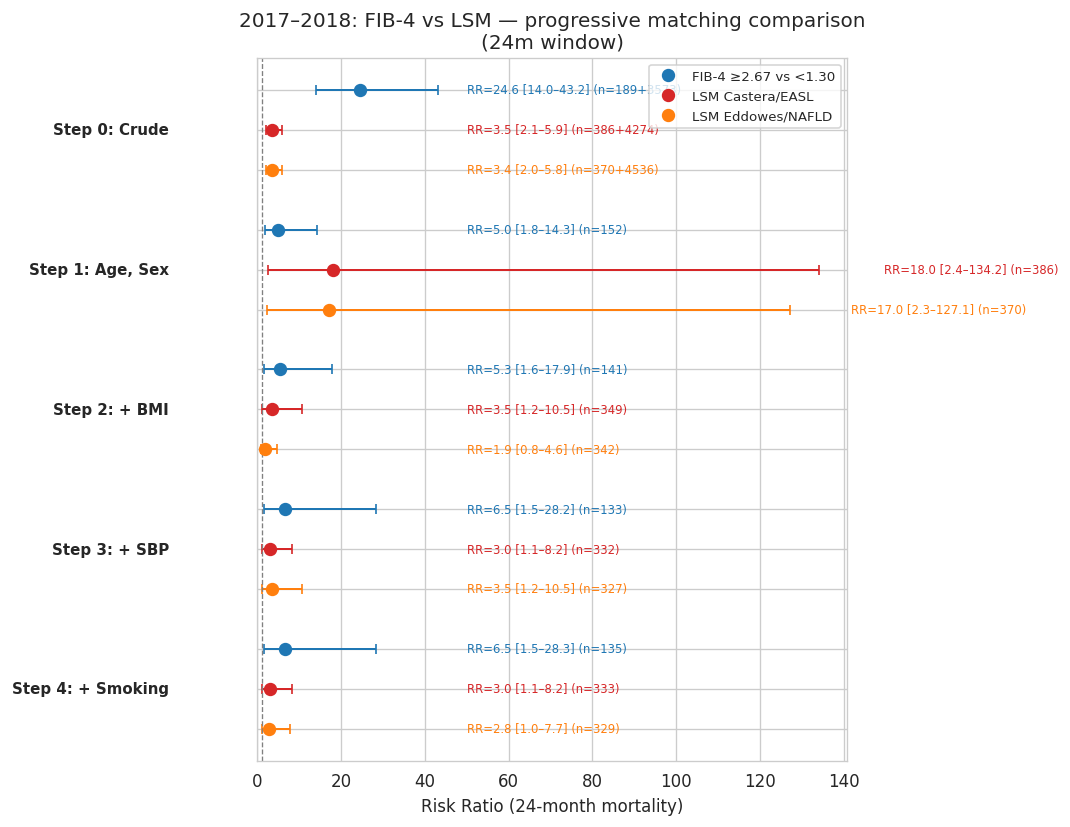

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

def_colors = {
    DEFINITIONS[0][0]: '#1f77b4',  # FIB-4: blue
    DEFINITIONS[1][0]: '#d62728',  # Castera: red
    DEFINITIONS[2][0]: '#ff7f0e',  # Eddowes: orange
}

y_pos = 0
y_ticks, y_labels_list = [], []
group_centers = []

for step_label in step_order:
    step_start = y_pos
    for def_label, _ in DEFINITIONS:
        res = results[def_label].get(step_label)
        if res is None:
            continue
        rr = res['rr']
        if rr is None or pd.isna(rr['RR']):
            y_ticks.append(y_pos)
            y_labels_list.append(def_label if step_label == 'Step 0: Crude' else '')
            y_pos += 1
            continue
        
        ax.errorbar(rr['RR'], y_pos,
                    xerr=[[rr['RR']-rr['lo']], [rr['hi']-rr['RR']]],
                    fmt='o', color=def_colors[def_label], capsize=3,
                    markersize=7, lw=1.2)
        
        n = res['n_pairs']
        n_str = f'n={n}' if n is not None else f"n={res['n_t']}+{res['n_c']}"
        ann = f"RR={rr['RR']:.1f} [{rr['lo']:.1f}\u2013{rr['hi']:.1f}] ({n_str})"
        # Place annotation to the right
        ax.text(max(50, rr['hi']*1.1 + 2), y_pos, ann, va='center', fontsize=7,
                color=def_colors[def_label])
        
        y_ticks.append(y_pos)
        y_labels_list.append('')
        y_pos += 1
    
    group_centers.append((step_start + y_pos - 1) / 2)
    y_pos += 0.5  # gap between steps

ax.axvline(1.0, color='gray', ls='--', lw=0.8)

# Add step labels on the left
for i, step_label in enumerate(step_order):
    if i < len(group_centers):
        ax.text(-0.15, group_centers[i], step_label, transform=ax.get_yaxis_transform(),
                ha='right', va='center', fontsize=9, fontweight='bold')

# Legend
for def_label, _ in DEFINITIONS:
    ax.plot([], [], 'o', color=def_colors[def_label], label=def_label, markersize=7)
ax.legend(loc='upper right', fontsize=8)

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels_list)
ax.invert_yaxis()
ax.set_xlabel(f'Risk Ratio ({WINDOW}-month mortality)')
ax.set_title(f'2017\u20132018: FIB-4 vs LSM \u2014 progressive matching comparison\n({WINDOW}m window)')
ax.set_xlim(left=0)
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.show()

## Matched KM curves at each step (all definitions)

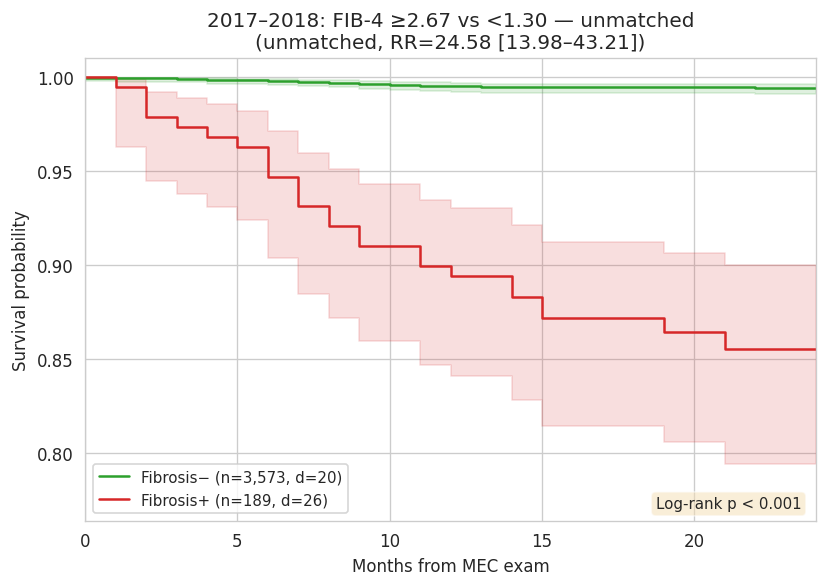

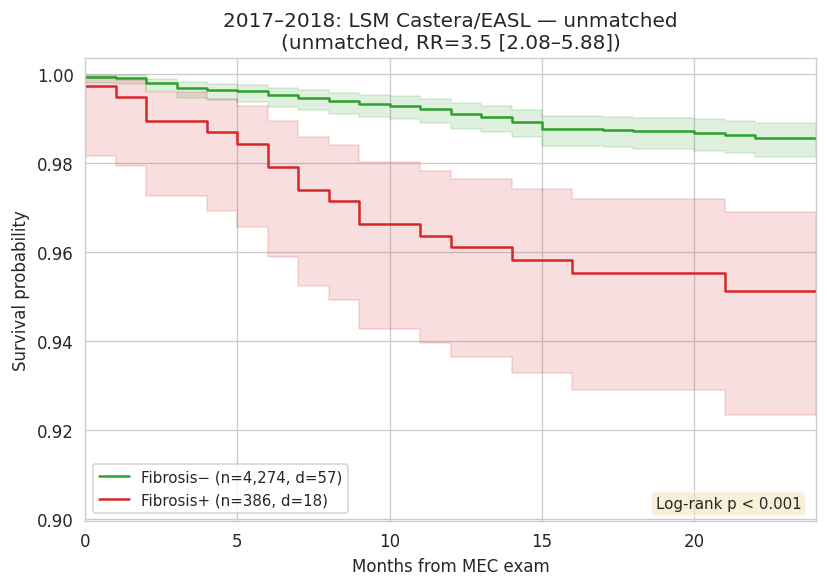

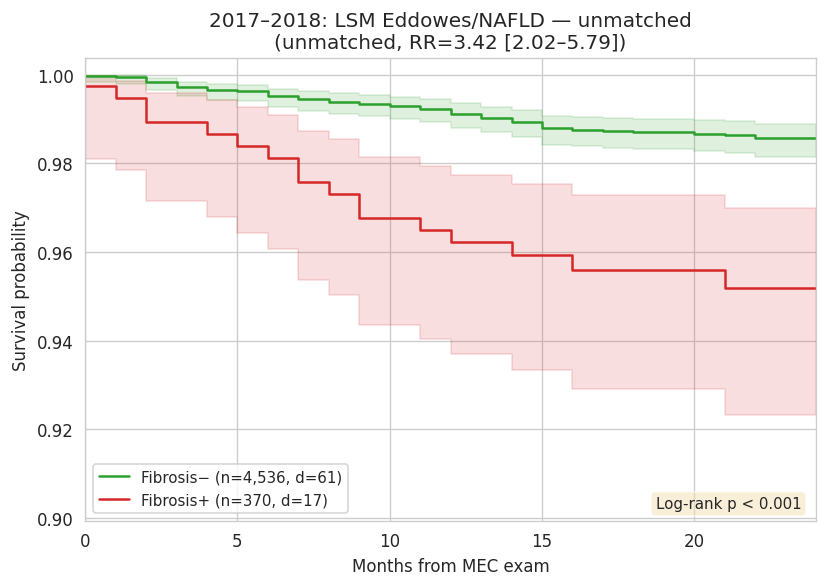

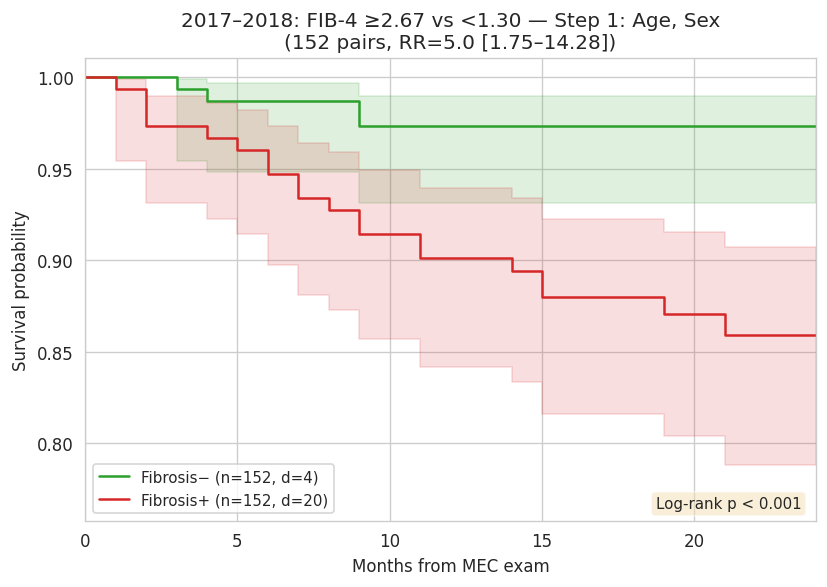

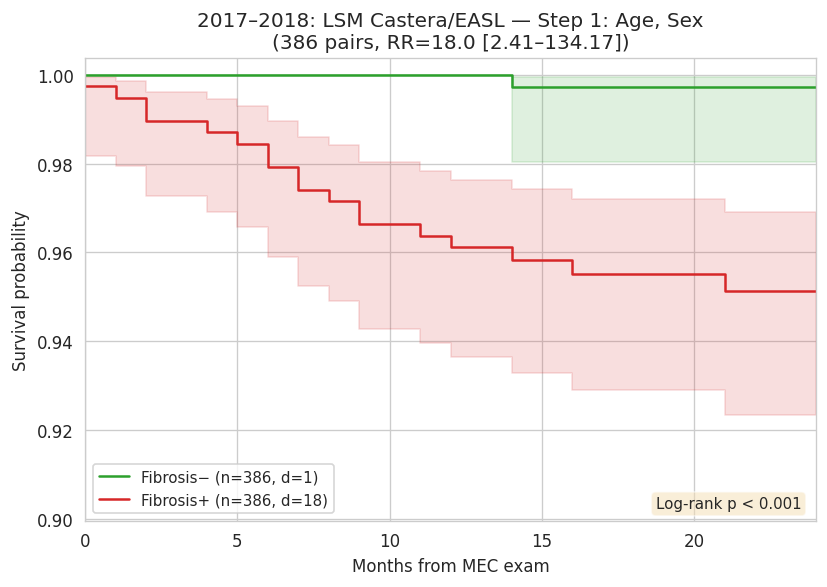

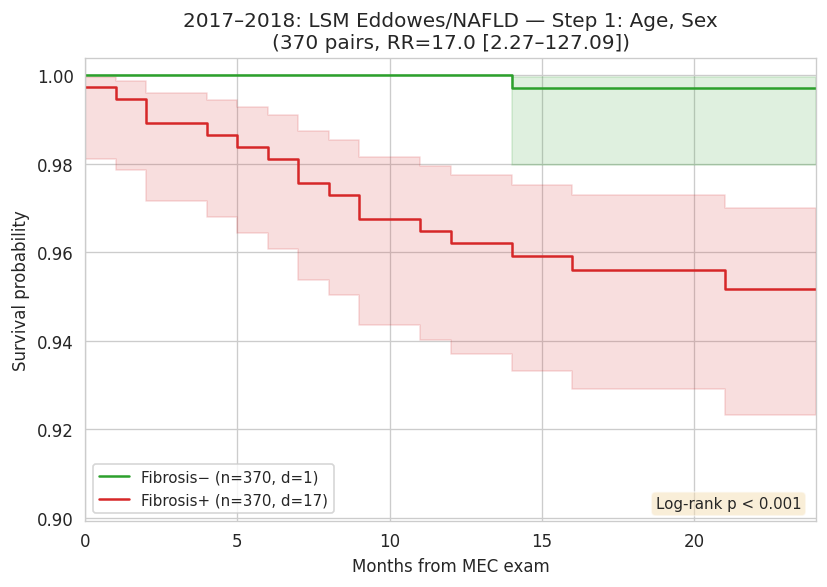

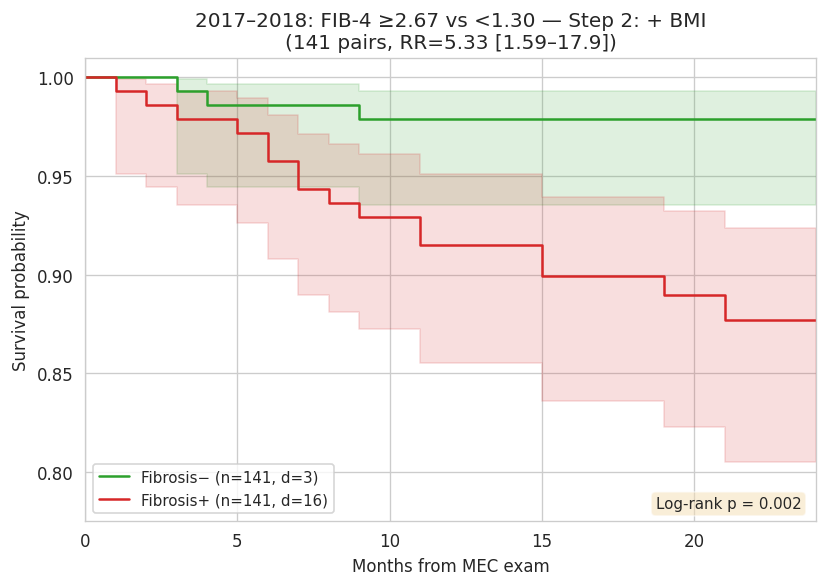

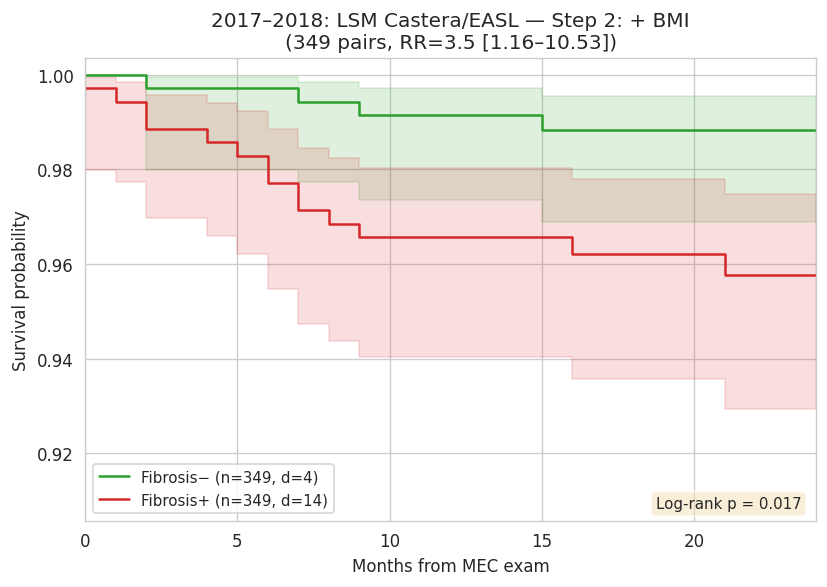

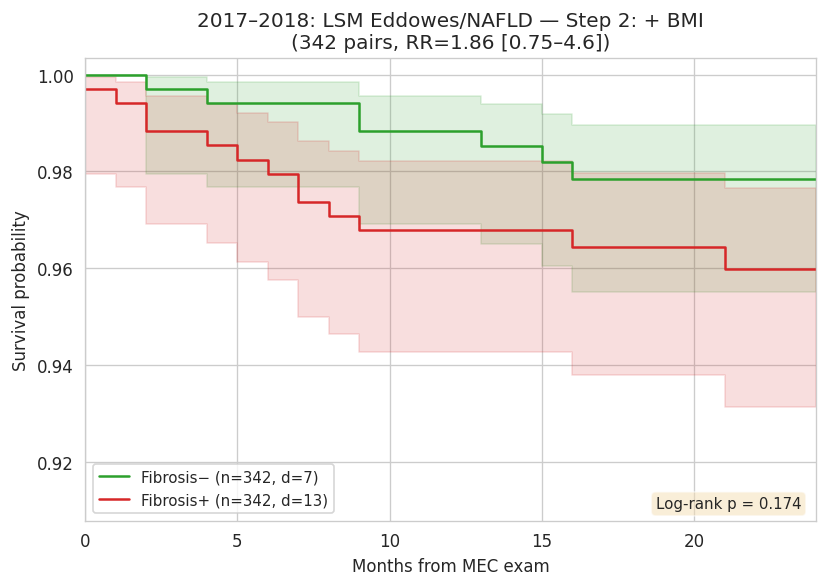

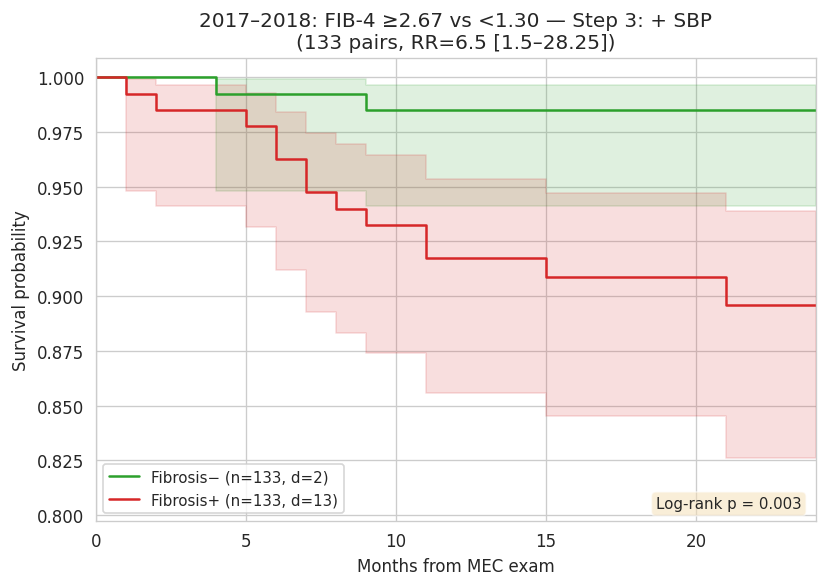

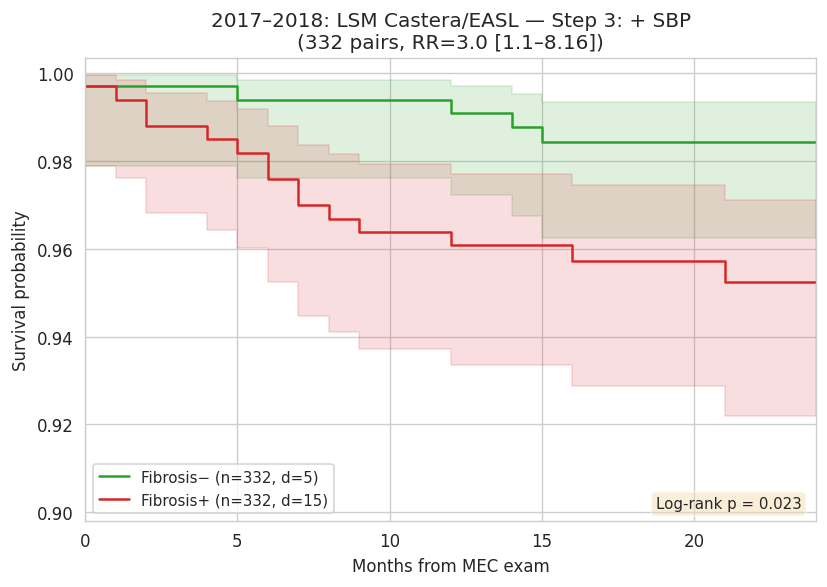

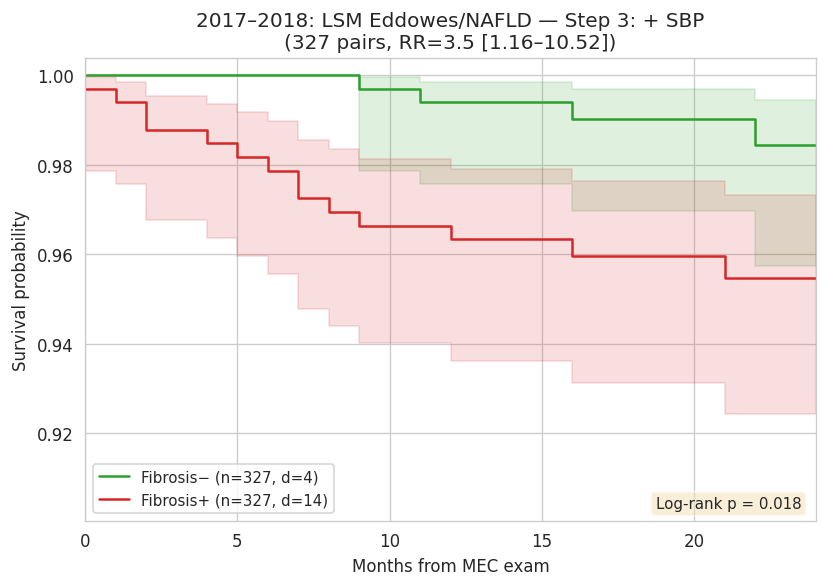

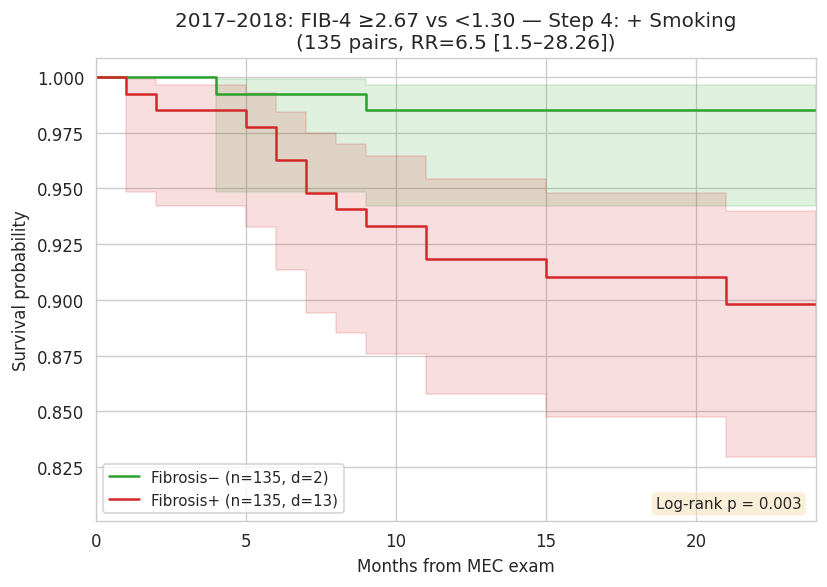

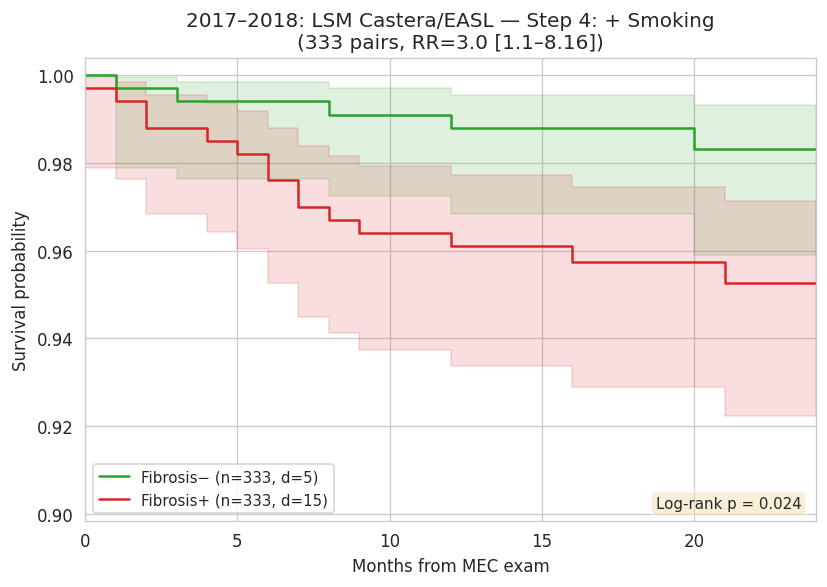

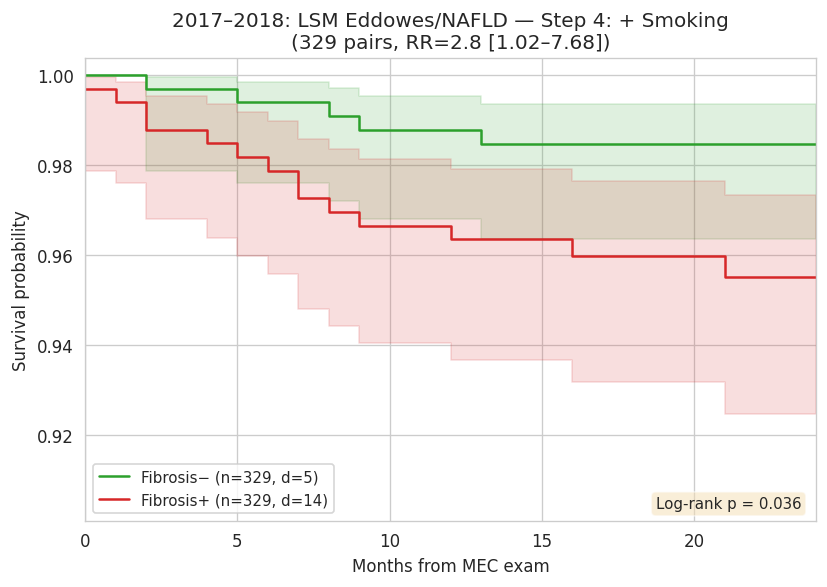

In [13]:
for step_label in step_order:
    for def_label, fib_col in DEFINITIONS:
        res = results[def_label].get(step_label)
        if res is None or len(res['matched']) == 0:
            continue
        rr = res['rr']
        rr_str = f'RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]' if (rr and pd.notna(rr['RR'])) else 'n/a'
        suffix = 'unmatched' if step_label == 'Step 0: Crude' else step_label
        n_pairs = res['n_pairs']
        n_str = f'{n_pairs} pairs' if n_pairs is not None else 'unmatched'
        plot_km(res['matched'], res['fib_col'], WINDOW,
                f'2017\u20132018: {def_label} \u2014 {suffix}\n({n_str}, {rr_str})')

## Overlap: who do the definitions capture?

In [14]:
# Venn-style summary: characteristics of fibrosis+ groups
desc_rows = []
for def_label, fib_col in DEFINITIONS:
    pos = df[df[fib_col]==1]
    neg = df[df[fib_col]==0]
    desc_rows.append({
        'Definition': def_label,
        'N(Fib+)': len(pos),
        'N(Fib\u2212)': len(neg),
        'Age+ (mean)': f"{pos['AGE'].mean():.1f}",
        'Age\u2212 (mean)': f"{neg['AGE'].mean():.1f}",
        'Female+ (%)': f"{(pos['FEMALE']==1).mean()*100:.0f}",
        'BMI+ (mean)': f"{pos['BMXBMI'].mean():.1f}",
        'BMI\u2212 (mean)': f"{neg['BMXBMI'].mean():.1f}",
        'Diabetes+ (%)': f"{(pos['SMOKE_EVER']==1).mean()*100:.0f}",
        'LSM+ (median kPa)': f"{pos['LSM_KPA'].median():.1f}" if pos['LSM_KPA'].notna().any() else 'n/a',
        'FIB4+ (median)': f"{pos['FIB4'].median():.2f}" if pos['FIB4'].notna().any() else 'n/a',
        '24m deaths': int(pos[f'DEATH_{WINDOW}m'].sum()),
        '24m risk': f"{pos[f'DEATH_{WINDOW}m'].mean()*100:.1f}%",
    })

desc_comp = pd.DataFrame(desc_rows)
desc_comp.T

,0,1,2
Definition,FIB-4 ≥2.67 vs <1.30,LSM Castera/EASL,LSM Eddowes/NAFLD
N(Fib+),189,386,370
N(Fib−),3573,4274,4536
Age+ (mean),70.1,56.3,56.1
Age− (mean),42.5,48.6,48.8
Female+ (%),37,40,40
BMI+ (mean),27.8,37.4,37.5
BMI− (mean),30.2,28.6,28.8
Diabetes+ (%),57,51,50
LSM+ (median kPa),6.7,12.7,13.0


## LSM severity levels: ≥F2 vs ≥F3 vs F4

Both Castera/EASL and Eddowes/NAFLD provide stage-specific cutpoints. Does
the mortality association strengthen at higher severity thresholds?

| Stage | Castera/EASL (kPa) | Eddowes/NAFLD (kPa) | Interpretation |
|---|---|---|---|
| F0–F1 (reference) | <7.1 | <8.2 | No/mild fibrosis |
| **≥F2** (significant) | ≥7.1 | ≥8.2 | Significant fibrosis |
| **≥F3** (advanced) | ≥9.5 | ≥9.7 | Bridging fibrosis |
| **F4** (cirrhosis) | ≥12.5 | ≥13.6 | Cirrhosis |

The ≥F3 analysis duplicates the LSM results above; including it here shows
the dose-response pattern across severity levels.

In [15]:
# Define fibrosis at each severity threshold
# Reference group is always F0-F1 (LSM below 'sig' cutpoint)

LSM_SEVERITY_DEFS = []

for cp_name, cp in LSM_CUTPOINTS.items():
    safe_name = cp_name.replace('/', '_')
    
    # ≥F2: significant fibrosis
    col_f2 = f'LSM_{safe_name}_geF2'
    df[col_f2] = np.nan
    ok_lsm = df['LSM_KPA'].notna()
    df.loc[ok_lsm & (df['LSM_KPA'] >= cp['sig']), col_f2] = 1   # ≥F2
    df.loc[ok_lsm & (df['LSM_KPA'] < cp['sig']),  col_f2] = 0   # F0-F1
    LSM_SEVERITY_DEFS.append((f'{cp_name} ≥F2 (≥{cp["sig"]} kPa)', col_f2, cp_name))
    
    # ≥F3: advanced fibrosis (same as existing analysis)
    col_f3 = f'LSM_{safe_name}_geF3'
    df[col_f3] = np.nan
    df.loc[ok_lsm & (df['LSM_KPA'] >= cp['adv']), col_f3] = 1   # ≥F3
    df.loc[ok_lsm & (df['LSM_KPA'] < cp['sig']),  col_f3] = 0   # F0-F1
    LSM_SEVERITY_DEFS.append((f'{cp_name} ≥F3 (≥{cp["adv"]} kPa)', col_f3, cp_name))
    
    # F4: cirrhosis
    col_f4 = f'LSM_{safe_name}_geF4'
    df[col_f4] = np.nan
    df.loc[ok_lsm & (df['LSM_KPA'] >= cp['cir']), col_f4] = 1   # F4
    df.loc[ok_lsm & (df['LSM_KPA'] < cp['sig']),  col_f4] = 0   # F0-F1
    LSM_SEVERITY_DEFS.append((f'{cp_name} F4 (≥{cp["cir"]} kPa)', col_f4, cp_name))

# Show group sizes
print(f'{"Definition":<40} {"Fib+":>6} {"Fib−":>6}')
print('-' * 55)
for label, col, _ in LSM_SEVERITY_DEFS:
    n_plus = int((df[col]==1).sum())
    n_minus = int((df[col]==0).sum())
    print(f'{label:<40} {n_plus:>6} {n_minus:>6}')

Definition                                 Fib+   Fib−
-------------------------------------------------------
Castera/EASL ≥F2 (≥7.1 kPa)                 817   4274
Castera/EASL ≥F3 (≥9.5 kPa)                 386   4274
Castera/EASL F4 (≥12.5 kPa)                 201   4274
Eddowes/NAFLD ≥F2 (≥8.2 kPa)                555   4536
Eddowes/NAFLD ≥F3 (≥9.7 kPa)                370   4536
Eddowes/NAFLD F4 (≥13.6 kPa)                169   4536


### Progressive matching at each LSM severity level

In [16]:
sev_results = {}

for def_label, fib_col, cp_name in LSM_SEVERITY_DEFS:
    sev_results[def_label] = {}
    print(f'\n{"="*60}')
    print(f'{def_label}')
    print(f'{"="*60}')
    
    # Step 0: Crude
    sub0 = df[df[fib_col].notna()].copy()
    rr0 = risk_ratio(sub0, fib_col, WINDOW)
    sev_results[def_label]['Step 0: Crude'] = {
        'matched': sub0, 'rr': rr0, 'n_pairs': None,
        'covariates': [], 'fib_col': fib_col,
        'n_t': int((sub0[fib_col]==1).sum()),
        'n_c': int((sub0[fib_col]==0).sum()),
    }
    rr_str = f'RR={rr0["RR"]} [{rr0["lo"]}\u2013{rr0["hi"]}]' if pd.notna(rr0['RR']) else 'n/a'
    print(f'  Crude: n+={rr0["n1"]}, n\u2212={rr0["n0"]}, d+={rr0["d1"]}, d\u2212={rr0["d0"]}, {rr_str}')
    
    for step in MATCH_STEPS:
        covs = step['covariates']
        label = step['label']
        mdf, n_t, n_c = propensity_match(df, fib_col, covs)
        if len(mdf) == 0:
            sev_results[def_label][label] = {
                'matched': pd.DataFrame(), 'rr': None, 'n_pairs': 0,
                'covariates': covs, 'fib_col': fib_col, 'n_t': n_t, 'n_c': n_c,
            }
            print(f'  {label}: no matches')
            continue
        
        ww = f'_{WINDOW}m'
        mdf[f'FU{ww}'] = mdf['PERMTH_EXM'].clip(upper=WINDOW)
        mdf[f'PY{ww}'] = mdf[f'FU{ww}'] / 12.0
        mdf[f'DEATH{ww}'] = ((mdf['MORTSTAT']==1) & (mdf['PERMTH_EXM']<=WINDOW)).astype(int)
        
        n_pairs = int((mdf[fib_col]==1).sum())
        rr = risk_ratio(mdf, fib_col, WINDOW)
        sev_results[def_label][label] = {
            'matched': mdf, 'rr': rr, 'n_pairs': n_pairs,
            'covariates': covs, 'fib_col': fib_col, 'n_t': n_t, 'n_c': n_c,
        }
        
        rr_str = f'RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]' if pd.notna(rr['RR']) else 'n/a'
        bal = covariate_balance(mdf, fib_col, all_covs)
        bal_str = ', '.join(f'{r["Covariate"]}={abs(r["SMD"]):.2f}'
                           for _, r in bal.iterrows() if pd.notna(r['SMD']))
        print(f'  {label}: {n_pairs} pairs, d+={rr["d1"]}, d\u2212={rr["d0"]}, {rr_str}')
        print(f'    Balance: {bal_str}')


Castera/EASL ≥F2 (≥7.1 kPa)
  Crude: n+=817, n−=4274, d+=27, d−=57, RR=2.48 [1.58–3.89]


  Step 1: Age, Sex: 817 pairs, d+=27, d−=8, RR=3.38 [1.54–7.38]
    Balance: AGE=0.00, FEMALE=0.00, BMXBMI=0.84, SBP_MEAN=0.23, SMOKE_EVER=0.09


  Step 2: + BMI: 747 pairs, d+=23, d−=10, RR=2.3 [1.1–4.8]
    Balance: AGE=0.09, FEMALE=0.01, BMXBMI=0.03, SBP_MEAN=0.08, SMOKE_EVER=0.02


  Step 3: + SBP: 715 pairs, d+=23, d−=11, RR=2.09 [1.03–4.26]
    Balance: AGE=0.02, FEMALE=0.00, BMXBMI=0.01, SBP_MEAN=0.03, SMOKE_EVER=0.04


  Step 4: + Smoking: 717 pairs, d+=23, d−=14, RR=1.64 [0.85–3.17]
    Balance: AGE=0.02, FEMALE=0.00, BMXBMI=0.02, SBP_MEAN=0.05, SMOKE_EVER=0.06

Castera/EASL ≥F3 (≥9.5 kPa)
  Crude: n+=386, n−=4274, d+=18, d−=57, RR=3.5 [2.08–5.88]
  Step 1: Age, Sex: 386 pairs, d+=18, d−=1, RR=18.0 [2.41–134.17]
    Balance: AGE=0.00, FEMALE=0.00, BMXBMI=1.08, SBP_MEAN=0.34, SMOKE_EVER=0.10


...

  Step 3: + SBP: 497 pairs, d+=19, d−=8, RR=2.38 [1.05–5.37]
    Balance: AGE=0.04, FEMALE=0.03, BMXBMI=0.02, SBP_MEAN=0.03, SMOKE_EVER=0.06


  Step 4: + Smoking: 496 pairs, d+=19, d−=7, RR=2.71 [1.15–6.4]
    Balance: AGE=0.01, FEMALE=0.03, BMXBMI=0.01, SBP_MEAN=0.04, SMOKE_EVER=0.05

Eddowes/NAFLD ≥F3 (≥9.7 kPa)
  Crude: n+=370, n−=4536, d+=17, d−=61, RR=3.42 [2.02–5.79]
  Step 1: Age, Sex: 370 pairs, d+=17, d−=1, RR=17.0 [2.27–127.09]
    Balance: AGE=0.00, FEMALE=0.00, BMXBMI=1.09, SBP_MEAN=0.35, SMOKE_EVER=0.12


  Step 2: + BMI: 342 pairs, d+=13, d−=7, RR=1.86 [0.75–4.6]
    Balance: AGE=0.07, FEMALE=0.01, BMXBMI=0.02, SBP_MEAN=0.03, SMOKE_EVER=0.00
  Step 3: + SBP: 327 pairs, d+=14, d−=4, RR=3.5 [1.16–10.52]
    Balance: AGE=0.04, FEMALE=0.03, BMXBMI=0.03, SBP_MEAN=0.02, SMOKE_EVER=0.09


  Step 4: + Smoking: 329 pairs, d+=14, d−=5, RR=2.8 [1.02–7.68]
    Balance: AGE=0.02, FEMALE=0.01, BMXBMI=0.02, SBP_MEAN=0.08, SMOKE_EVER=0.02

Eddowes/NAFLD F4 (≥13.6 kPa)
  Crude: n+=169, n−=4536, d+=9, d−=61, RR=3.96 [2.0–7.84]
  Step 1: Age, Sex: 169 pairs, d+=9, d−=1, RR=9.0 [1.15–70.26]
    Balance: AGE=0.00, FEMALE=0.00, BMXBMI=1.15, SBP_MEAN=0.46, SMOKE_EVER=0.01
  Step 2: + BMI: 156 pairs, d+=8, d−=4, RR=2.0 [0.61–6.51]
    Balance: AGE=0.05, FEMALE=0.22, BMXBMI=0.09, SBP_MEAN=0.04, SMOKE_EVER=0.05


  Step 3: + SBP: 147 pairs, d+=8, d−=1, RR=8.0 [1.01–63.16]
    Balance: AGE=0.05, FEMALE=0.06, BMXBMI=0.00, SBP_MEAN=0.06, SMOKE_EVER=0.03
  Step 4: + Smoking: 147 pairs, d+=8, d−=3, RR=2.67 [0.72–9.85]
    Balance: AGE=0.07, FEMALE=0.11, BMXBMI=0.01, SBP_MEAN=0.04, SMOKE_EVER=0.03


### Severity summary table

In [17]:
sev_summary_rows = []
for def_label, fib_col, cp_name in LSM_SEVERITY_DEFS:
    for step_label in step_order:
        res = sev_results[def_label].get(step_label)
        if res is None:
            continue
        rr = res['rr']
        row = {
            'Cutpoints': cp_name,
            'Threshold': def_label.split('(')[0].strip().split()[-1],  # ≥F2, ≥F3, F4
            'Step': step_label,
            'N+': res['n_t'],
            'N\u2212': res['n_c'],
            'Pairs': res['n_pairs'] if res['n_pairs'] is not None else f"{res['n_t']}v{res['n_c']}",
        }
        if rr and pd.notna(rr['RR']):
            row.update({'d+': rr['d1'], 'd\u2212': rr['d0'],
                        'RR': rr['RR'], '95% CI': f"{rr['lo']}\u2013{rr['hi']}"})
        else:
            row.update({'d+': rr['d1'] if rr else '\u2014', 'd\u2212': rr['d0'] if rr else '\u2014',
                        'RR': '\u2014', '95% CI': '\u2014'})
        sev_summary_rows.append(row)

sev_df = pd.DataFrame(sev_summary_rows)
display(sev_df)

,Cutpoints,Threshold,Step,N+,N−,Pairs,d+,d−,RR,95% CI
0,Castera/EASL,≥F2,Step 0: Crude,817,4274,817v4274,27,57,2.48,1.58–3.89
1,Castera/EASL,≥F2,"Step 1: Age, Sex",817,4274,817,27,8,3.38,1.54–7.38
2,Castera/EASL,≥F2,Step 2: + BMI,806,4240,747,23,10,2.30,1.1–4.8
3,Castera/EASL,≥F2,Step 3: + SBP,774,4071,715,23,11,2.09,1.03–4.26
4,Castera/EASL,≥F2,Step 4: + Smoking,774,4071,717,23,14,1.64,0.85–3.17
5,Castera/EASL,≥F3,Step 0: Crude,386,4274,386v4274,18,57,3.50,2.08–5.88
6,Castera/EASL,≥F3,"Step 1: Age, Sex",386,4274,386,18,1,18.00,2.41–134.17
7,Castera/EASL,≥F3,Step 2: + BMI,379,4240,349,14,4,3.50,1.16–10.53
8,Castera/EASL,≥F3,Step 3: + SBP,362,4071,332,15,5,3.00,1.1–8.16
9,Castera/EASL,≥F3,Step 4: + Smoking,362,4071,333,15,5,3.00,1.1–8.16


### Forest plot: LSM severity dose-response (Step 4 matched)

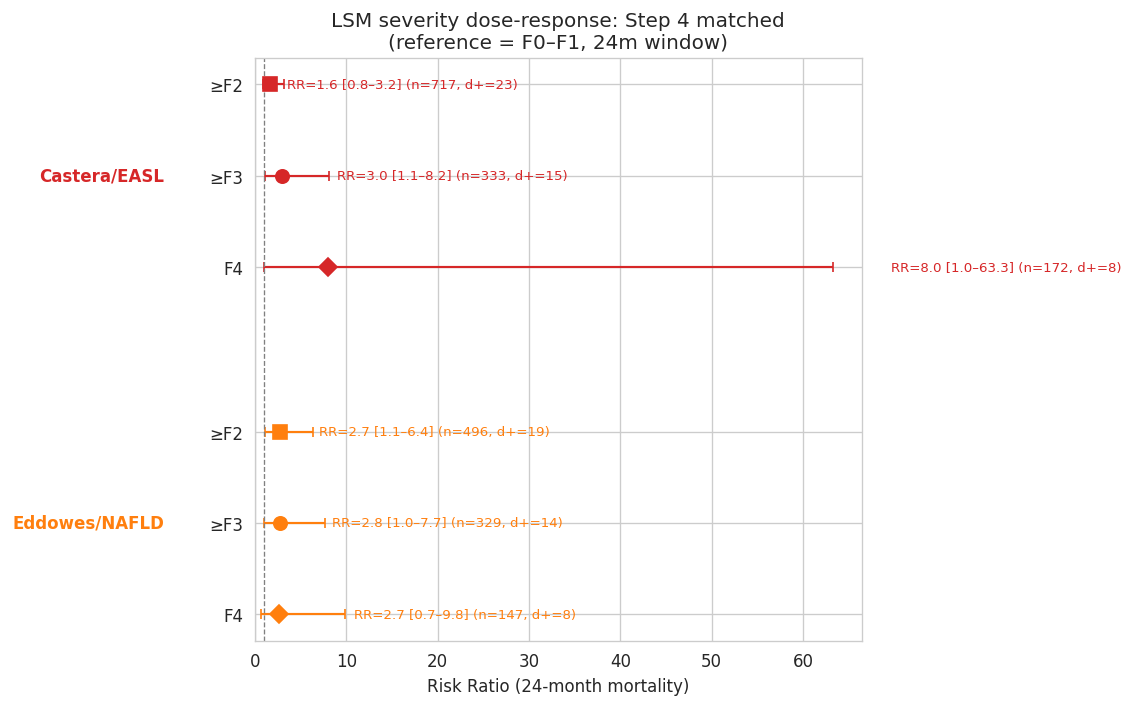

In [18]:
# Forest plot showing dose-response: ≥F2, ≥F3, F4 for each cutpoint system
fig, ax = plt.subplots(figsize=(10, 6))

cp_colors = {'Castera/EASL': '#d62728', 'Eddowes/NAFLD': '#ff7f0e'}
stage_markers = {'\u2265F2': 's', '\u2265F3': 'o', 'F4': 'D'}

y_pos = 0
y_ticks, y_labels_list = [], []
group_centers = {}

s4_label = 'Step 4: + Smoking'

for cp_name in LSM_CUTPOINTS:
    group_start = y_pos
    for def_label, fib_col, cp in LSM_SEVERITY_DEFS:
        if cp != cp_name:
            continue
        res = sev_results[def_label].get(s4_label)
        if res is None:
            continue
        rr = res['rr']
        
        # Extract stage label
        stage = def_label.split('(')[0].strip().split()[-1]
        
        if rr is None or pd.isna(rr.get('RR', np.nan)):
            y_ticks.append(y_pos)
            y_labels_list.append(f'{stage}')
            ann = f'n/a (n+={res["n_t"]})'
            ax.text(0.5, y_pos, ann, va='center', fontsize=8, color='gray')
            y_pos += 1
            continue
        
        marker = stage_markers.get(stage, 'o')
        color = cp_colors[cp_name]
        ax.errorbar(rr['RR'], y_pos,
                    xerr=[[rr['RR']-rr['lo']], [rr['hi']-rr['RR']]],
                    fmt=marker, color=color, capsize=3,
                    markersize=8, lw=1.3)
        
        n = res['n_pairs']
        n_str = f'n={n}' if n else f"n={res['n_t']}"
        ann = f"RR={rr['RR']:.1f} [{rr['lo']:.1f}\u2013{rr['hi']:.1f}] ({n_str}, d+={rr['d1']})"
        ax.text(max(rr['hi']*1.1, rr['RR']+1), y_pos, ann, va='center', fontsize=8,
                color=color)
        
        y_ticks.append(y_pos)
        y_labels_list.append(f'{stage}')
        y_pos += 1
    
    group_centers[cp_name] = (group_start + y_pos - 1) / 2
    y_pos += 0.8  # gap between cutpoint systems

ax.axvline(1.0, color='gray', ls='--', lw=0.8)

# Add cutpoint system labels
for cp_name, center in group_centers.items():
    ax.text(-0.15, center, cp_name, transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=10, fontweight='bold',
            color=cp_colors[cp_name])

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels_list)
ax.invert_yaxis()
ax.set_xlabel(f'Risk Ratio ({WINDOW}-month mortality)')
ax.set_title(f'LSM severity dose-response: Step 4 matched\n'
             f'(reference = F0\u2013F1, {WINDOW}m window)')
ax.set_xlim(left=0)
plt.tight_layout()
plt.subplots_adjust(left=0.25)
plt.show()

### Step 4 matched KM curves at each severity level

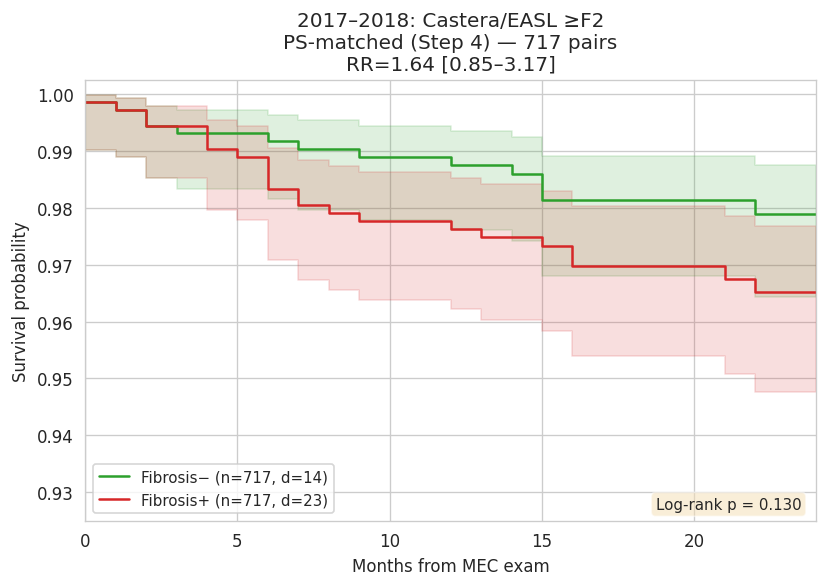

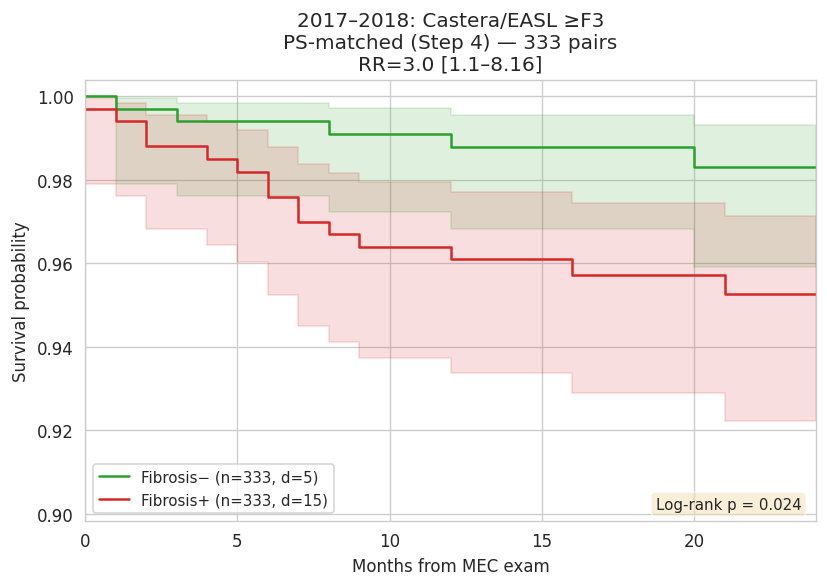

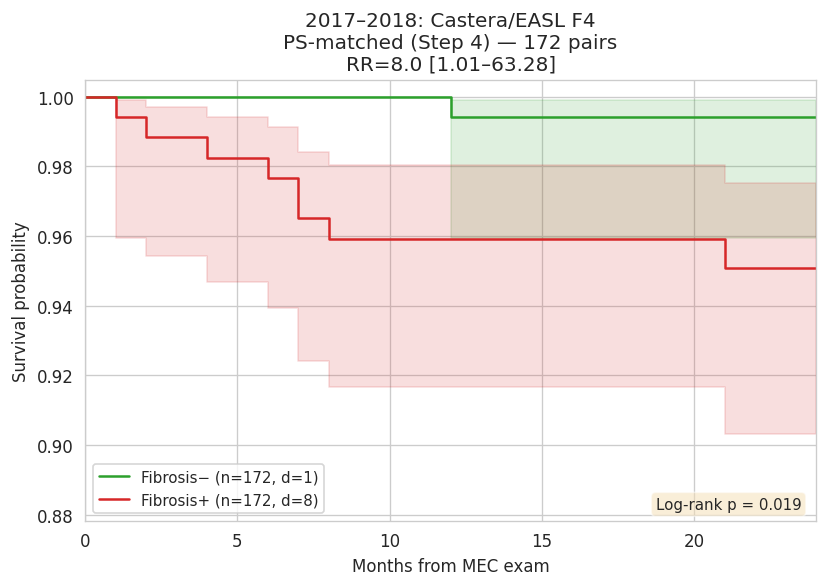

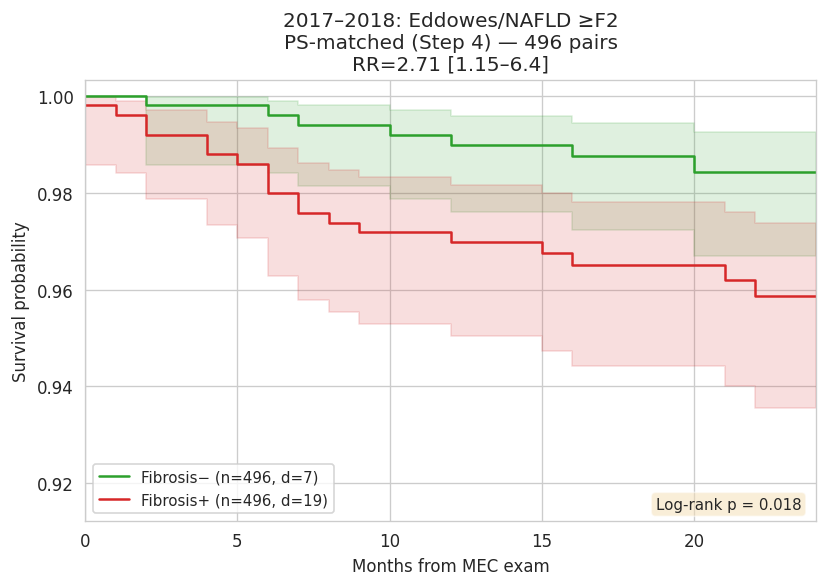

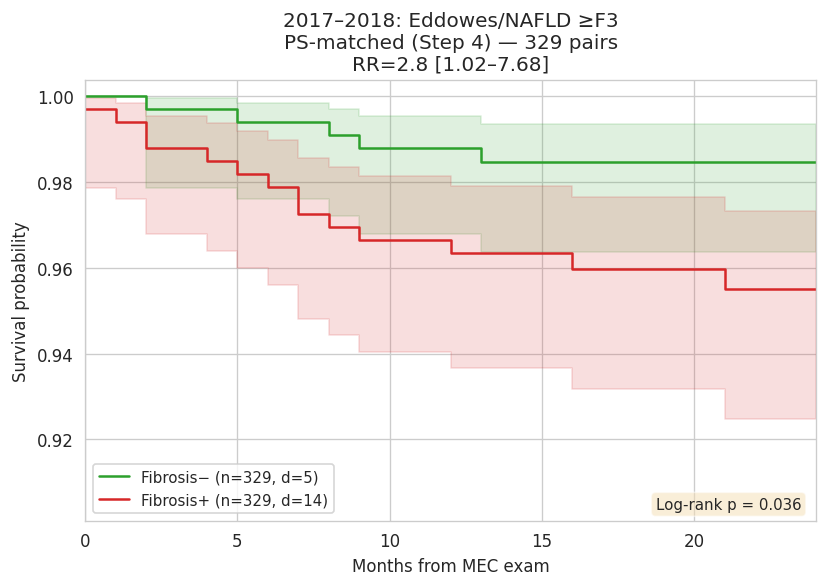

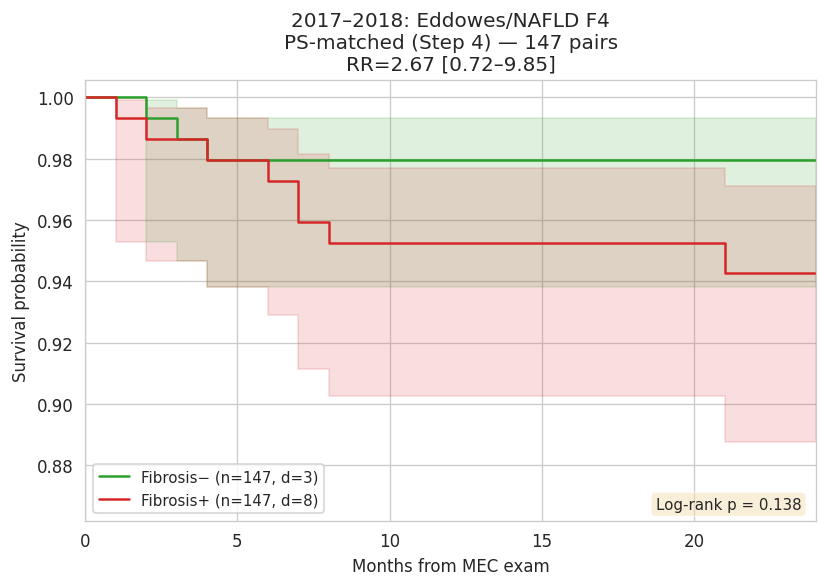

In [19]:
for def_label, fib_col, cp_name in LSM_SEVERITY_DEFS:
    res = sev_results[def_label].get('Step 4: + Smoking')
    if res is None or len(res['matched']) == 0:
        print(f'{def_label}: no Step 4 matches')
        continue
    
    rr = res['rr']
    rr_str = f'RR={rr["RR"]} [{rr["lo"]}\u2013{rr["hi"]}]' if pd.notna(rr['RR']) else 'n/a'
    n_pairs = res['n_pairs']
    
    # Extract stage for label
    stage = def_label.split('(')[0].strip()
    
    plot_km(res['matched'], fib_col, WINDOW,
            f'2017\u20132018: {stage}\n'
            f'PS-matched (Step 4) \u2014 {n_pairs} pairs\n'
            f'{rr_str}')

### Crude and matched risk by severity level

In [20]:
en = '–'
dash = '—'

def fmt_rr(rr):
    if not rr or pd.isna(rr.get('RR', np.nan)):
        return dash
    return f"{rr['RR']} [{rr['lo']}{en}{rr['hi']}]"

# Compact comparison: crude and Step 4 matched RR for each threshold
dose_rows = []
for def_label, fib_col, cp_name in LSM_SEVERITY_DEFS:
    stage = def_label.split('(')[0].strip().split()[-1]
    crude = sev_results[def_label].get('Step 0: Crude', {})
    s4 = sev_results[def_label].get('Step 4: + Smoking', {})
    
    crude_rr = crude.get('rr')
    s4_rr = s4.get('rr')
    
    dose_rows.append({
        'Cutpoints': cp_name,
        'Threshold': stage,
        'N+': crude.get('n_t', '—'),
        'Crude RR': fmt_rr(crude_rr),
        'Matched pairs': s4.get('n_pairs', '—'),
        'Matched RR': fmt_rr(s4_rr),
        'Crude 24m risk (Fib+)': f"{crude_rr['d1']/crude_rr['n1']*100:.1f}%" if crude_rr and crude_rr['n1']>0 else '—',
    })

dose_df = pd.DataFrame(dose_rows)
display(dose_df)

interp = (
    "**Interpretation:** Higher LSM thresholds identify smaller, sicker groups with "
    "progressively higher crude mortality risk. The dose-response pattern supports "
    "the clinical staging—F4 (cirrhosis) carries more risk than ≥F3 (bridging), "
    "which carries more than ≥F2 (significant). After matching, confidence intervals "
    "widen for F4 due to fewer subjects, but point estimates generally increase with "
    "severity."
)
display(Markdown(interp))

,Cutpoints,Threshold,N+,Crude RR,Matched pairs,Matched RR,Crude 24m risk (Fib+)
0,Castera/EASL,≥F2,817,2.48 [1.58–3.89],717,1.64 [0.85–3.17],3.3%
1,Castera/EASL,≥F3,386,3.5 [2.08–5.88],333,3.0 [1.1–8.16],4.7%
2,Castera/EASL,F4,201,3.73 [1.93–7.2],172,8.0 [1.01–63.28],5.0%
3,Eddowes/NAFLD,≥F2,555,3.08 [1.92–4.94],496,2.71 [1.15–6.4],4.1%
4,Eddowes/NAFLD,≥F3,370,3.42 [2.02–5.79],329,2.8 [1.02–7.68],4.6%
5,Eddowes/NAFLD,F4,169,3.96 [2.0–7.84],147,2.67 [0.72–9.85],5.3%


**Interpretation:** Higher LSM thresholds identify smaller, sicker groups with progressively higher crude mortality risk. The dose-response pattern supports the clinical staging—F4 (cirrhosis) carries more risk than ≥F3 (bridging), which carries more than ≥F2 (significant). After matching, confidence intervals widen for F4 due to fewer subjects, but point estimates generally increase with severity.

## Summary

In [21]:
en = '\u2013'
dash = '\u2014'
geq = '\u2265'

def fmt_rr(rr):
    if not rr or pd.isna(rr.get('RR', np.nan)):
        return dash
    return f"{rr['RR']} [{rr['lo']}{en}{rr['hi']}]"

# Get Step 4 results for each
s4_label = 'Step 4: + Smoking'
rows = []
for def_label, _ in DEFINITIONS:
    crude = results[def_label].get('Step 0: Crude', {})
    s4 = results[def_label].get(s4_label, {})
    rows.append({
        'Definition': def_label,
        'N+': crude.get('n_t', dash),
        'N\u2212': crude.get('n_c', dash),
        'Crude RR': fmt_rr(crude.get('rr')),
        'Matched pairs': s4.get('n_pairs', dash),
        'Matched RR': fmt_rr(s4.get('rr')),
    })

comp_df = pd.DataFrame(rows)
display(comp_df)

summary_text = f"""
### FIB-4 vs LSM: head-to-head comparison (2017{en}2018, {WINDOW}m window)

**Key findings:**

1. **FIB-4 has a much higher crude RR** (~25\u00d7) than LSM (~3.5\u00d7) because FIB-4
   embeds age in its formula, creating strong confounding with age-related mortality.

2. **After matching on age+sex+BMI+SBP+smoking (Step 4)**, the definitions converge:
   all show elevated mortality in the fibrosis+ group, though confidence intervals
   are wide due to few events.

3. **LSM identifies more fibrosis+ subjects** (~370{en}386 vs 189 for FIB-4) and
   achieves more matched pairs, but these groups only partially overlap.

4. **Cross-classification shows limited concordance**: many subjects are fibrosis+
   by one definition but fibrosis{en} by the other, reflecting different biological
   signals (liver stiffness vs serological markers).

**Limitation:** The 2017{en}2018 cycle has short follow-up (~48% reach 24m), so
death counts are small. The pooled 10-cycle analysis (notebook 03) provides much
tighter estimates for FIB-4, but LSM is only available in this single cycle.
"""

display(Markdown(summary_text))

,Definition,N+,N−,Crude RR,Matched pairs,Matched RR
0,FIB-4 ≥2.67 vs <1.30,189,3573,24.58 [13.98–43.21],135,6.5 [1.5–28.26]
1,LSM Castera/EASL,386,4274,3.5 [2.08–5.88],333,3.0 [1.1–8.16]
2,LSM Eddowes/NAFLD,370,4536,3.42 [2.02–5.79],329,2.8 [1.02–7.68]



### FIB-4 vs LSM: head-to-head comparison (2017–2018, 24m window)

**Key findings:**

1. **FIB-4 has a much higher crude RR** (~25×) than LSM (~3.5×) because FIB-4
   embeds age in its formula, creating strong confounding with age-related mortality.

2. **After matching on age+sex+BMI+SBP+smoking (Step 4)**, the definitions converge:
   all show elevated mortality in the fibrosis+ group, though confidence intervals
   are wide due to few events.

3. **LSM identifies more fibrosis+ subjects** (~370–386 vs 189 for FIB-4) and
   achieves more matched pairs, but these groups only partially overlap.

4. **Cross-classification shows limited concordance**: many subjects are fibrosis+
   by one definition but fibrosis– by the other, reflecting different biological
   signals (liver stiffness vs serological markers).

**Limitation:** The 2017–2018 cycle has short follow-up (~48% reach 24m), so
death counts are small. The pooled 10-cycle analysis (notebook 03) provides much
tighter estimates for FIB-4, but LSM is only available in this single cycle.
